In [2]:
!pip install pandas
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 907.3 kB/s eta 0:00:000:00:010:00:01:01


In [1]:
# Import essential libraries
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import time

# Authenticate
api = KaggleApi()
api.authenticate()

dataset = 'blastchar/telco-customer-churn'
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
# Define the dataset ID and the CSV filename inside the zip
dataset = 'blastchar/telco-customer-churn'
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Check if the file exists locally FIRST
if not os.path.exists(file_name):
    print("File not found. Downloading now (this will take a moment)...")
    # force=False means: "Only download if the file is missing"
    api.dataset_download_file(dataset, file_name=file_name, force=False)
    print("Download complete!")
else:
    print("File already exists. Skipping download completely!")

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

# Start analyzing data
print(df.head())

File already exists. Skipping download completely!
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSuppo

In [5]:
# Shape of the dataset
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Data types and non‑null counts
df.info()

Dataset has 7043 rows and 21 columns.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilli

In [6]:
# Summary Statistics for Numerical Columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Count of churn vs non‑churn
churn_counts = df["Churn"].value_counts()
print(churn_counts)

# Percentage
print(f"\nChurn rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%


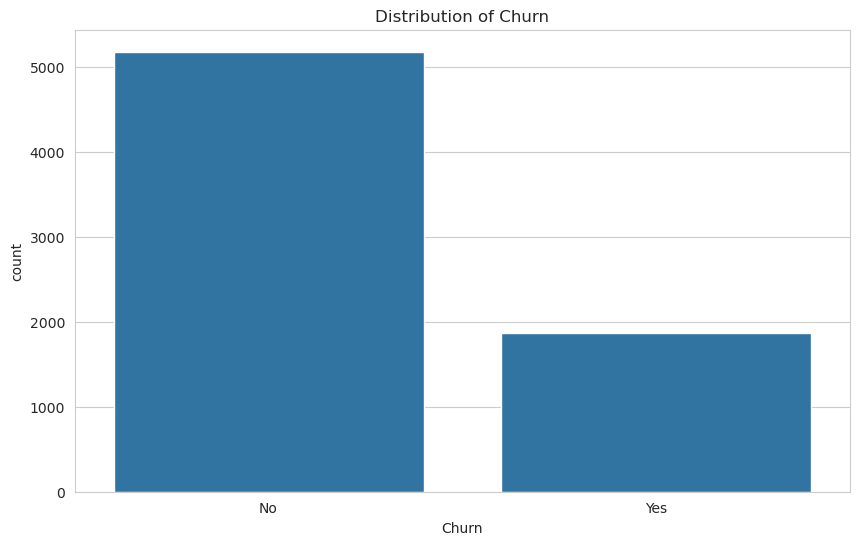

In [8]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Visualise
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.show()

In [11]:
# Identify categorical columns (object type)
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

# Safely exclude columns we don't want as features, even if they aren't in the list
exclude_cols = ["customerID", "Churn"]
cat_cols = [col for col in cat_cols if col not in exclude_cols]

# Numerical columns (int64, float64)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", cat_cols)
print("Numerical features:", num_cols)

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [ ]:
print()

In [14]:
!ls

Untitled.ipynb	WA_Fn-UseC_-Telco-Customer-Churn.csv
